# 🛡️ Projet GLM : Modélisation de la Fréquence des Cyberattaques
**Réalisé par :** Hajar Hayeb & Atika Mahfoud  
**Cadre :** Module des Modèles Linéaires Généralisés (GLM) — INSEA
***


---
## 1. Chargement des Bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.genmod.families import NegativeBinomial
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             roc_curve, auc)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Bibliothèques chargées avec succès.")


✅ Bibliothèques chargées avec succès.


---
## 2. Description des Donnée

In [2]:
# Chargement
df = pd.read_csv('Test_data.csv')
print(f"Dimensions : {df.shape[0]} observations × {df.shape[1]} variables")
df.head()


Dimensions : 22544 observations × 41 variables


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,private,REJ,0,0,0,0,0,0,...,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00
1,0,tcp,private,REJ,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71


In [3]:
# Valeurs manquantes
missing_total = df.isnull().sum().sum()
print(f"Valeurs manquantes totales : {missing_total}")
print("✅ Aucune valeur manquante." if missing_total == 0 else "⚠️ Valeurs manquantes présentes.")

# Types de variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nVariables catégorielles ({len(cat_cols)}) : {cat_cols}")
print(f"Variables numériques     ({len(num_cols)})")


Valeurs manquantes totales : 0
✅ Aucune valeur manquante.

Variables catégorielles (3) : ['protocol_type', 'service', 'flag']
Variables numériques     (38)


In [4]:
# Statistiques descriptives
df.describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
duration,22544.0,218.859,1407.177,0.0,0.00,0.00,0.000,57715.0
src_bytes,22544.0,10395.450,472786.431,0.0,0.00,54.00,287.000,62825648.0
dst_bytes,22544.0,2056.019,21219.298,0.0,0.00,46.00,601.000,1345927.0
land,22544.0,0.000,0.018,0.0,0.00,0.00,0.000,1.0
wrong_fragment,22544.0,0.008,0.143,0.0,0.00,0.00,0.000,3.0
urgent,22544.0,0.001,0.036,0.0,0.00,0.00,0.000,3.0
hot,22544.0,0.105,0.928,0.0,0.00,0.00,0.000,101.0
num_failed_logins,22544.0,0.022,0.150,0.0,0.00,0.00,0.000,4.0
logged_in,22544.0,0.442,0.497,0.0,0.00,0.00,1.000,1.0
num_compromised,22544.0,0.120,7.270,0.0,0.00,0.00,0.000,796.0


In [5]:
# Distribution des variables catégorielles
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())



--- protocol_type ---
protocol_type
tcp     18880
udp      2621
icmp     1043

--- service ---
service
http           7853
private        4774
telnet         1626
pop_3          1019
smtp            934
domain_u        894
ftp_data        851
other           838
ecr_i           752
ftp             692
imap4           306
eco_i           262
sunrpc          159
finger          136
auth             67
domain           51
uucp             50
iso_tsap         48
bgp              46
uucp_path        46
Z39_50           45
vmnet            43
nnsp             42
ctf              41
link             41
whois            40
courier          40
name             37
echo             37
http_443         36
time             36
netbios_ns       36
csnet_ns         34
gopher           34
efs              33
mtp              32
systat           32
login            29
daytime          28
supdup           27
exec             27
netstat          26
discard          26
ssh              26
netbios_dgm     

### 3. Analyse de la Variable de Réponse : `count`

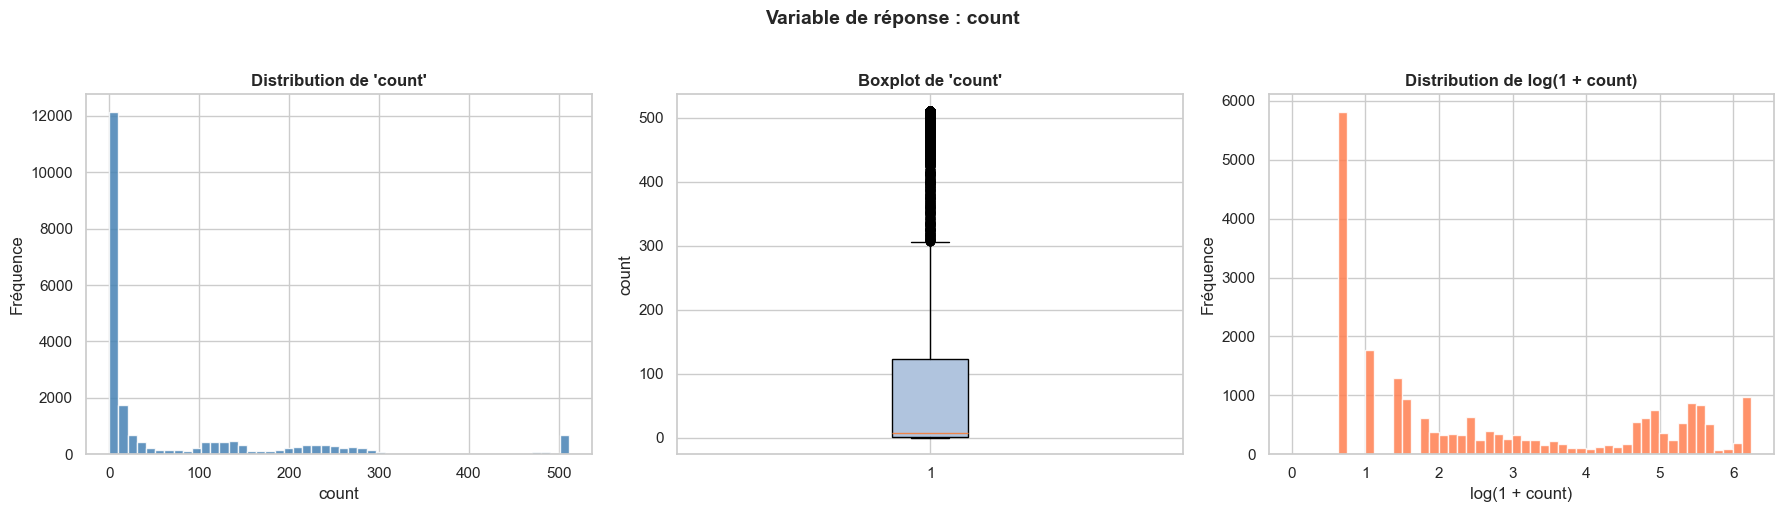

  Moyenne  : 79.0283
  Variance : 16522.3382
  Ratio V/M: 209.07  (>> 1 → surdispersion)
  Min / Max: 0 / 511


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['count'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title("Distribution de 'count'", fontweight='bold')
axes[0].set_xlabel('count'); axes[0].set_ylabel('Fréquence')

axes[1].boxplot(df['count'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue'))
axes[1].set_title("Boxplot de 'count'", fontweight='bold'); axes[1].set_ylabel('count')

axes[2].hist(np.log1p(df['count']), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[2].set_title('Distribution de log(1 + count)', fontweight='bold')
axes[2].set_xlabel('log(1 + count)'); axes[2].set_ylabel('Fréquence')

plt.suptitle("Variable de réponse : count", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_distribution_count.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  Moyenne  : {df['count'].mean():.4f}")
print(f"  Variance : {df['count'].var():.4f}")
print(f"  Ratio V/M: {df['count'].var()/df['count'].mean():.2f}  (>> 1 → surdispersion)")
print(f"  Min / Max: {df['count'].min()} / {df['count'].max()}")


In [7]:
# Test de surdispersion
mean_y = df['count'].mean()
var_y  = df['count'].var()
ratio  = var_y / mean_y

print("=" * 55)
print("TEST DE SURDISPERSION")
print("=" * 55)
print(f"  Moyenne (μ)   : {mean_y:.4f}")
print(f"  Variance (σ²) : {var_y:.4f}")
print(f"  Ratio σ²/μ    : {ratio:.2f}")
print()
if ratio > 1:
    print(f"⚠️  Surdispersion détectée (ratio = {ratio:.2f} >> 1).")
    print("   → Modèle Quasi-Poisson / Binomial Négatif recommandé en complément.")
else:
    print("✅ Pas de surdispersion. Poisson est approprié.")


TEST DE SURDISPERSION
  Moyenne (μ)   : 79.0283
  Variance (σ²) : 16522.3382
  Ratio σ²/μ    : 209.07

⚠️  Surdispersion détectée (ratio = 209.07 >> 1).
   → Modèle Quasi-Poisson / Binomial Négatif recommandé en complément.


### 3.2 Analyse Exploratoire

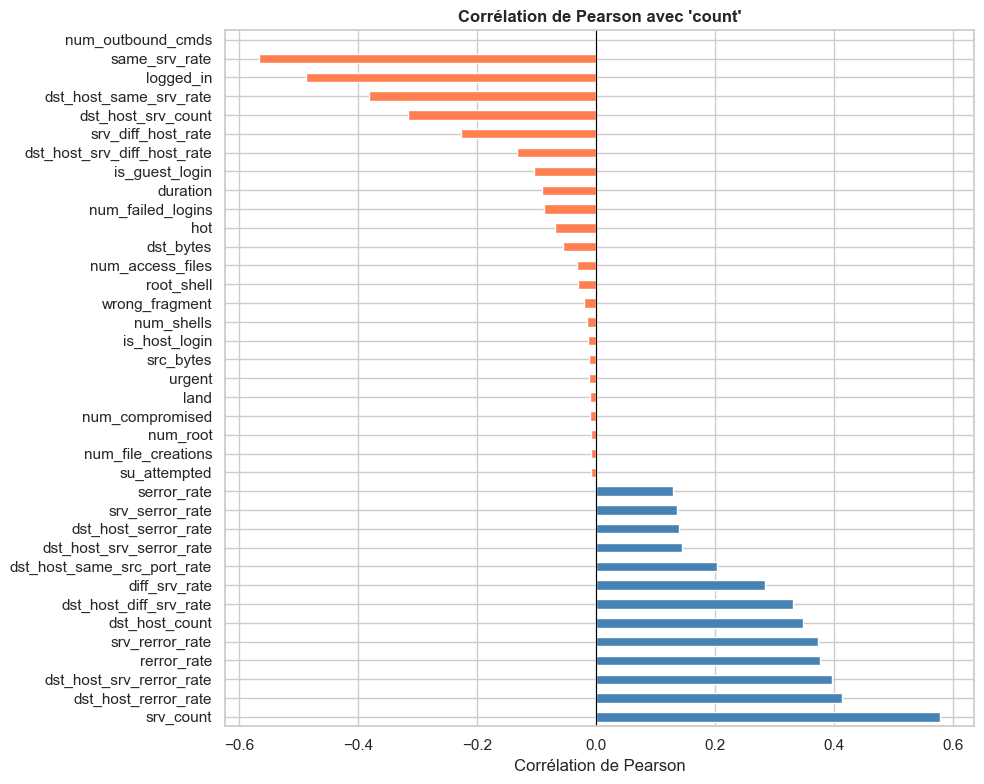

In [8]:
# Corrélation des variables numériques avec 'count'
corr_count = df[num_cols].corr()['count'].drop('count').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_count.plot(kind='barh', color=['steelblue' if v >= 0 else 'coral' for v in corr_count])
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Corrélation de Pearson avec 'count'", fontweight='bold')
plt.xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


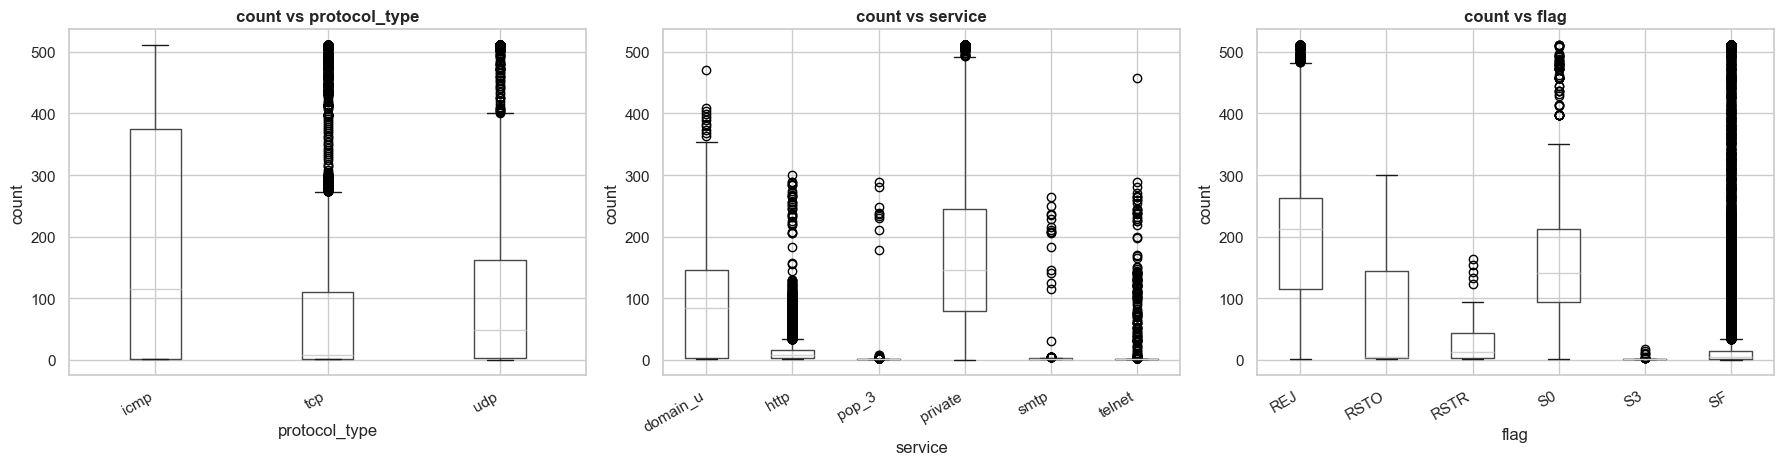

In [9]:
# Boxplot count vs variables catégorielles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    top_cats = df[col].value_counts().head(6).index
    df_f = df[df[col].isin(top_cats)]
    df_f.boxplot(column='count', by=col, ax=ax)
    ax.set_title(f"count vs {col}", fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('count')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.suptitle('')
plt.tight_layout()
plt.savefig('fig3_boxplot_categoriel.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Préparation des Données

In [10]:
# Suppression des observations avec count = 0 (pour éviter log(0))
data = df[df['count'] > 0].copy()
print(f"Observations retenues : {len(data)} / {len(df)}")

# Regroupement du service (64 modalités → 7) : top 6 + 'other'
top_services = data['service'].value_counts().head(6).index.tolist()
data['service_grp'] = data['service'].apply(
    lambda x: x if x in top_services else 'other'
)
print("\nModalités de service_grp :")
print(data['service_grp'].value_counts().to_string())


Observations retenues : 22543 / 22544

Modalités de service_grp :
service_grp
http        7853
other       5444
private     4773
telnet      1626
pop_3       1019
smtp         934
domain_u     894


In [11]:
# Variables retenues pour la modélisation
features = [
    'duration', 'protocol_type', 'service_grp', 'flag',
    'src_bytes', 'dst_bytes', 'logged_in', 'wrong_fragment',
    'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_serror_rate', 'dst_host_rerror_rate'
]
target = 'count'

data_model = data[features + [target]].copy()

# Division 80% / 20%
train_data, test_data = train_test_split(data_model, test_size=0.2, random_state=42)

print(f"Échantillon d'apprentissage : {len(train_data)} obs. ({len(train_data)/len(data_model)*100:.1f}%)")
print(f"Échantillon de validation   : {len(test_data)} obs. ({len(test_data)/len(data_model)*100:.1f}%)")


Échantillon d'apprentissage : 18034 obs. (80.0%)
Échantillon de validation   : 4509 obs. (20.0%)


---
## 5. Modélisation : Régression de Poisson

Le modèle de Poisson s'écrit :

$$\log(\mu_i) = \beta_0 + \beta_1 X_{1i} + \cdots + \beta_p X_{pi}, \quad Y_i \sim \text{Poisson}(\mu_i)$$

La fonction de lien est le **logarithme** (lien canonique de la loi de Poisson).  
Les paramètres sont estimés par **maximum de vraisemblance** via l'algorithme IRLS.


### 5.1 Modèle Complet

In [12]:
formula_full = (
    "count ~ duration + C(protocol_type) + C(service_grp) + C(flag) "
    "+ np.log1p(src_bytes) + np.log1p(dst_bytes) + logged_in + wrong_fragment "
    "+ serror_rate + rerror_rate + same_srv_rate + diff_srv_rate "
    "+ dst_host_count + dst_host_srv_count "
    "+ dst_host_same_srv_rate + dst_host_diff_srv_rate "
    "+ dst_host_serror_rate + dst_host_rerror_rate"
)

model_full = smf.glm(
    formula=formula_full,
    data=train_data,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit(maxiter=200)

print(model_full.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                18034
Model:                            GLM   Df Residuals:                    18000
Model Family:                 Poisson   Df Model:                           33
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.0528e+05
Date:                Mon, 25 May 2026   Deviance:                   7.3128e+05
Time:                        19:41:03   Pearson chi2:                 8.94e+05
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### 5.2 Modèle Réduit (variables les plus significatives)

In [13]:
formula_reduced = (
    "count ~ C(protocol_type) + C(flag) "
    "+ logged_in + serror_rate + rerror_rate "
    "+ same_srv_rate + diff_srv_rate "
    "+ dst_host_count + dst_host_srv_count"
)

model_reduced = smf.glm(
    formula=formula_reduced,
    data=train_data,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit(maxiter=200)

print(model_reduced.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                18034
Model:                            GLM   Df Residuals:                    18014
Model Family:                 Poisson   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.9839e+05
Date:                Mon, 25 May 2026   Deviance:                   9.1749e+05
Time:                        19:41:03   Pearson chi2:                 1.13e+06
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

### 5.3 Modèle Binomial Négatif (robuste à la surdispersion)

In [14]:
model_nb = smf.glm(
    formula=formula_reduced,
    data=train_data,
    family=NegativeBinomial()
).fit(maxiter=200)

print(model_nb.summary())


c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                18034
Model:                            GLM   Df Residuals:                    18014
Model Family:        NegativeBinomial   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -75809.
Date:                Mon, 25 May 2026   Deviance:                       20229.
Time:                        19:41:03   Pearson chi2:                 2.19e+04
No. Iterations:                    21   Pseudo R-squ. (CS):             0.9041
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

---
## 6. Test d'Adéquation du Modèle

In [15]:
# Comparaison AIC / BIC / Déviance / Pseudo-R²
print("=" * 65)
print("COMPARAISON DES MODÈLES (échantillon d'apprentissage)")
print("=" * 65)

comparison = pd.DataFrame({
    'Modèle'    : ['Poisson Complet', 'Poisson Réduit', 'Binomial Négatif'],
    'AIC'       : [model_full.aic,  model_reduced.aic,  model_nb.aic],
    'BIC'       : [model_full.bic,  model_reduced.bic,  model_nb.bic],
    'Déviance'  : [model_full.deviance, model_reduced.deviance, model_nb.deviance],
    'Pseudo-R²' : [
        1 - model_full.deviance    / model_full.null_deviance,
        1 - model_reduced.deviance / model_reduced.null_deviance,
        1 - model_nb.deviance      / model_nb.null_deviance
    ]
})
pd.set_option('display.float_format', '{:.2f}'.format)
print(comparison.to_string(index=False))

best_aic = comparison.loc[comparison['AIC'].idxmin(), 'Modèle']
best_r2  = comparison.loc[comparison['Pseudo-R²'].idxmax(), 'Modèle']
print(f"\n✅ Meilleur AIC    : {best_aic}")
print(f"✅ Meilleur Pseudo-R² : {best_r2}")


COMPARAISON DES MODÈLES (échantillon d'apprentissage)
          Modèle       AIC        BIC  Déviance  Pseudo-R²
 Poisson Complet 810628.29  554880.57 731280.82       0.75
  Poisson Réduit 996812.09  740955.17 917492.63       0.69
Binomial Négatif 151658.22 -156308.56  20228.90       0.68

✅ Meilleur AIC    : Binomial Négatif
✅ Meilleur Pseudo-R² : Poisson Complet


In [16]:
# Test du rapport de vraisemblance (Complet vs Réduit)
lr_stat = 2 * (model_full.llf - model_reduced.llf)
df_diff = model_full.df_model - model_reduced.df_model
p_lr    = 1 - stats.chi2.cdf(lr_stat, df=df_diff)

print("=" * 60)
print("TEST DU RAPPORT DE VRAISEMBLANCE (Complet vs Réduit)")
print("=" * 60)
print(f"  Statistique LR       : {lr_stat:.4f}")
print(f"  Degrés de liberté    : {int(df_diff)}")
print(f"  p-valeur (χ²)        : {p_lr:.6f}")
print()
if p_lr < 0.05:
    print("⚠️  Différence significative → le modèle COMPLET apporte de l'information.")
else:
    print("✅ Pas de différence significative → modèle RÉDUIT préféré (parcimonie).")


TEST DU RAPPORT DE VRAISEMBLANCE (Complet vs Réduit)
  Statistique LR       : 186211.8019
  Degrés de liberté    : 14
  p-valeur (χ²)        : 0.000000

⚠️  Différence significative → le modèle COMPLET apporte de l'information.


In [17]:
# Test d'adéquation : déviance résiduelle
deviance_red = model_reduced.deviance
df_resid_red = model_reduced.df_resid
p_gof        = 1 - stats.chi2.cdf(deviance_red, df=df_resid_red)

print("=" * 60)
print("TEST D'ADÉQUATION — MODÈLE POISSON RÉDUIT")
print("=" * 60)
print(f"  Déviance résiduelle  : {deviance_red:.2f}")
print(f"  Degrés de liberté    : {df_resid_red}")
print(f"  p-valeur (χ²)        : {p_gof:.6f}")
print()
if p_gof < 0.05:
    print("⚠️  Manque d'adéquation détecté (surdispersion confirmée).")
    print("   → Modèle Binomial Négatif recommandé.")
else:
    print("✅ Modèle adéquat.")


TEST D'ADÉQUATION — MODÈLE POISSON RÉDUIT
  Déviance résiduelle  : 917492.63
  Degrés de liberté    : 18014
  p-valeur (χ²)        : 0.000000

⚠️  Manque d'adéquation détecté (surdispersion confirmée).
   → Modèle Binomial Négatif recommandé.


### 6.1 Analyse des Résidus

In [ ]:
pearson_resid  = model_reduced.resid_pearson
deviance_resid = model_reduced.resid_deviance
fitted_vals    = model_reduced.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Résidus de Pearson vs valeurs ajustées
axes[0,0].scatter(fitted_vals, pearson_resid, alpha=0.25, s=8, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0,0].set_xlabel('Valeurs ajustées'); axes[0,0].set_ylabel('Résidus de Pearson')
axes[0,0].set_title('Résidus de Pearson vs Valeurs ajustées', fontweight='bold')

# 2. QQ-Plot
pp = ProbPlot(deviance_resid)
pp.qqplot(line='s', ax=axes[0,1], alpha=0.3)
axes[0,1].set_title('QQ-Plot des résidus de déviance', fontweight='bold')

# 3. Histogramme
axes[1,0].hist(pearson_resid, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1,0].set_xlabel('Résidus de Pearson'); axes[1,0].set_ylabel('Fréquence')
axes[1,0].set_title('Distribution des résidus de Pearson', fontweight='bold')

# 4. Scale-Location
axes[1,1].scatter(fitted_vals, np.sqrt(np.abs(pearson_resid)), alpha=0.25, s=8, color='seagreen')
axes[1,1].set_xlabel('Valeurs ajustées'); axes[1,1].set_ylabel('√|Résidus de Pearson|')
axes[1,1].set_title('Scale-Location', fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_residus.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Courbe ROC et Comparaison des Modèles

In [ ]:
# Binarisation pour la courbe ROC : count > médiane = 1 (fort trafic)
median_count = train_data['count'].median()
print(f"Médiane de 'count' (seuil de binarisation) : {median_count}")

y_test     = test_data['count'].values
y_test_bin = (y_test > median_count).astype(int)
print(f"Classe 1 (count > {median_count}) : {y_test_bin.sum()} obs. ({y_test_bin.mean()*100:.1f}%)")
print(f"Classe 0 (count ≤ {median_count}) : {(1-y_test_bin).sum()} obs.")


Médiane de 'count' (seuil de binarisation) : 8.0
Classe 1 (count > 8.0) : 2166 obs. (48.0%)
Classe 0 (count ≤ 8.0) : 2343 obs.


In [ ]:
# Prédictions sur l'échantillon de validation
pred_full    = model_full.predict(test_data)
pred_reduced = model_reduced.predict(test_data)
pred_nb      = model_nb.predict(test_data)

# Normalisation min-max pour les scores ROC
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

# Courbes ROC
fpr_full, tpr_full, _ = roc_curve(y_test_bin, normalize(pred_full))
fpr_red,  tpr_red,  _ = roc_curve(y_test_bin, normalize(pred_reduced))
fpr_nb,   tpr_nb,   _ = roc_curve(y_test_bin, normalize(pred_nb))

auc_full    = auc(fpr_full, tpr_full)
auc_reduced = auc(fpr_red,  tpr_red)
auc_nb      = auc(fpr_nb,   tpr_nb)

print(f"AUC — Poisson Complet    : {auc_full:.4f}")
print(f"AUC — Poisson Réduit     : {auc_reduced:.4f}")
print(f"AUC — Binomial Négatif   : {auc_nb:.4f}")


AUC — Poisson Complet    : 0.8678
AUC — Poisson Réduit     : 0.8604
AUC — Binomial Négatif   : 0.8822


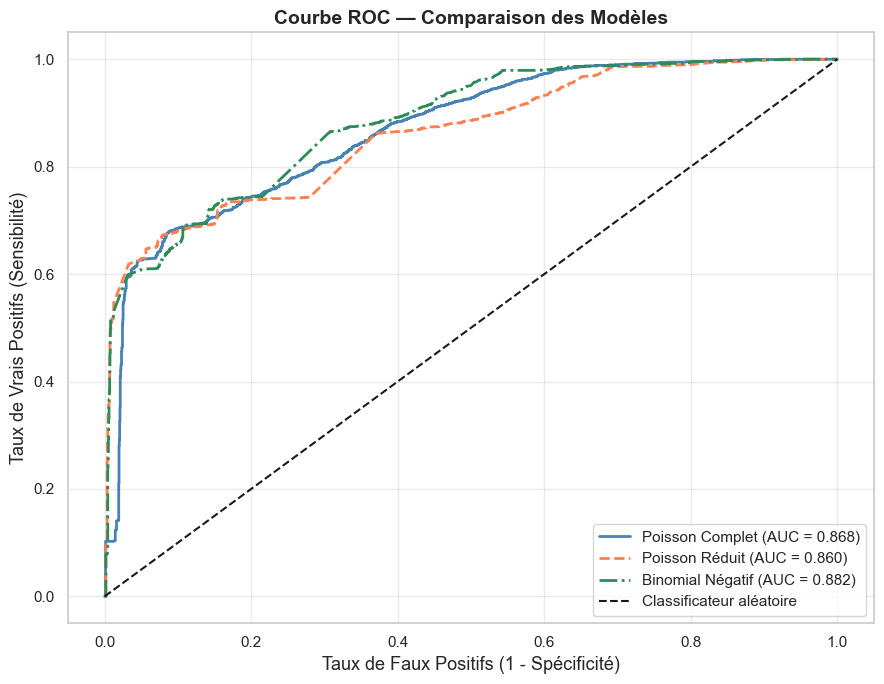

In [ ]:
# Tracé des courbes ROC
plt.figure(figsize=(9, 7))
plt.plot(fpr_full, tpr_full,
         label=f'Poisson Complet (AUC = {auc_full:.3f})', lw=2, color='steelblue')
plt.plot(fpr_red, tpr_red,
         label=f'Poisson Réduit (AUC = {auc_reduced:.3f})', lw=2, color='coral', linestyle='--')
plt.plot(fpr_nb, tpr_nb,
         label=f'Binomial Négatif (AUC = {auc_nb:.3f})', lw=2, color='seagreen', linestyle='-.')
plt.plot([0,1], [0,1], 'k--', lw=1.5, label='Classificateur aléatoire')
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=13)
plt.ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=13)
plt.title('Courbe ROC — Comparaison des Modèles', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig5_courbe_roc.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Évaluation sur l'Échantillon de Validation

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

metrics = pd.DataFrame({
    'Modèle' : ['Poisson Complet', 'Poisson Réduit', 'Binomial Négatif'],
    'MAE'    : [mean_absolute_error(y_test, pred_full),
                mean_absolute_error(y_test, pred_reduced),
                mean_absolute_error(y_test, pred_nb)],
    'RMSE'   : [rmse(y_test, pred_full),
                rmse(y_test, pred_reduced),
                rmse(y_test, pred_nb)],
    'AUC-ROC': [auc_full, auc_reduced, auc_nb]
})

print("=" * 60)
print("MÉTRIQUES DE PERFORMANCE (échantillon de validation — 20%)")
print("=" * 60)
pd.set_option('display.float_format', '{:.4f}'.format)
print(metrics.to_string(index=False))
print()
best = metrics.loc[metrics['AUC-ROC'].idxmax(), 'Modèle']
print(f"✅ Meilleur AUC-ROC : {best}")


MÉTRIQUES DE PERFORMANCE (échantillon de validation — 20%)
          Modèle     MAE    RMSE  AUC-ROC
 Poisson Complet 36.6789 76.5010   0.8678
  Poisson Réduit 42.7467 85.4105   0.8604
Binomial Négatif 45.6851 97.9495   0.8822

✅ Meilleur AUC-ROC : Binomial Négatif


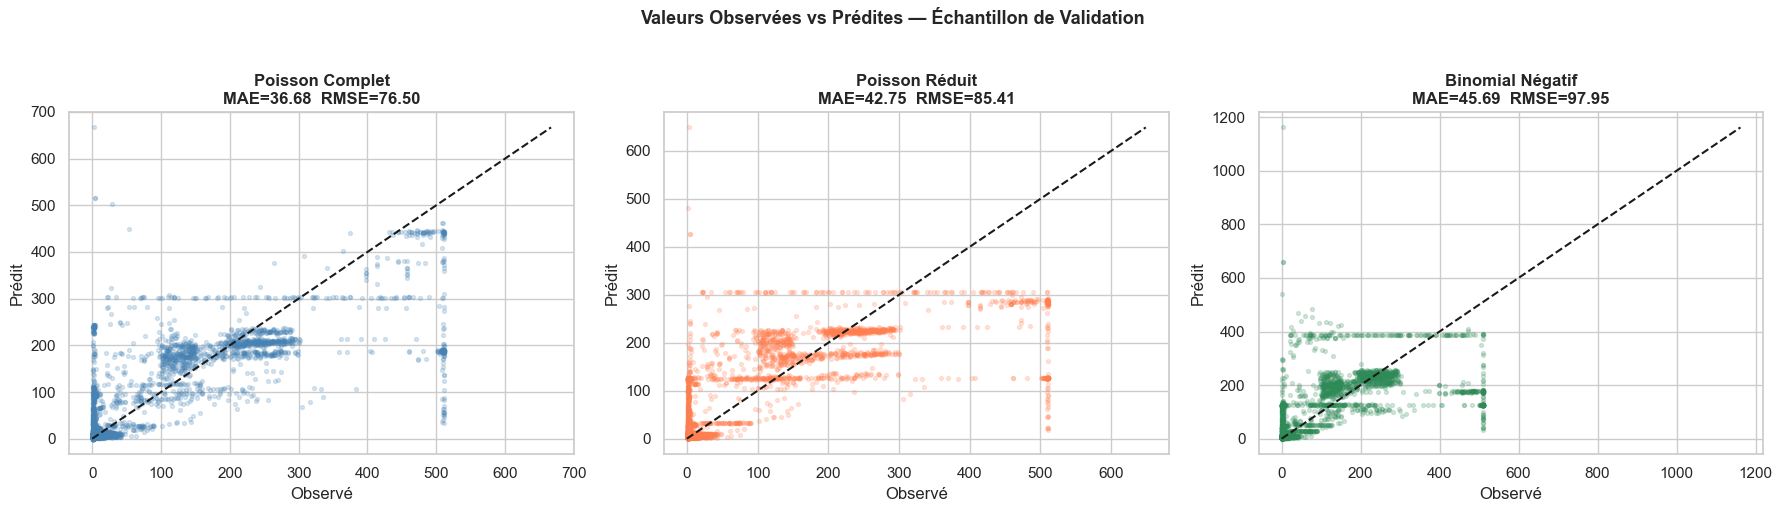

In [ ]:
# Valeurs observées vs prédites
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
pairs = [
    ('Poisson Complet',    pred_full,    'steelblue'),
    ('Poisson Réduit',     pred_reduced, 'coral'),
    ('Binomial Négatif',   pred_nb,      'seagreen'),
]
for ax, (name, pred, col) in zip(axes, pairs):
    ax.scatter(y_test, pred, alpha=0.2, s=8, color=col)
    lim = max(y_test.max(), pred.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1.5)
    ax.set_xlabel('Observé'); ax.set_ylabel('Prédit')
    ax.set_title(f'{name}\nMAE={mean_absolute_error(y_test,pred):.2f}  RMSE={rmse(y_test,pred):.2f}',
                 fontweight='bold')

plt.suptitle('Valeurs Observées vs Prédites — Échantillon de Validation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_obs_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Interprétation des Résultats

In [ ]:
# Tableau des IRR (Incidence Rate Ratios) du modèle réduit
coef_df = pd.DataFrame({
    'β (Coefficient)' : model_reduced.params,
    'IRR = exp(β)'    : np.exp(model_reduced.params),
    'p-valeur'        : model_reduced.pvalues,
    'IC 2.5%'         : np.exp(model_reduced.conf_int()[0]),
    'IC 97.5%'        : np.exp(model_reduced.conf_int()[1])
})
coef_df['Significatif (p<0.05)'] = coef_df['p-valeur'] < 0.05

print("=" * 75)
print("TABLEAU DES IRR — MODÈLE POISSON RÉDUIT")
print("=" * 75)
print(coef_df.round(4).to_string())


TABLEAU DES IRR — MODÈLE POISSON RÉDUIT
                         β (Coefficient)  IRR = exp(β)  p-valeur  IC 2.5%  IC 97.5%  Significatif (p<0.05)
Intercept                         4.2026       66.8608    0.0000  25.0842  178.2143                   True
C(protocol_type)[T.tcp]          -3.0455        0.0476    0.0000   0.0468    0.0484                   True
C(protocol_type)[T.udp]          -0.8895        0.4108    0.0000   0.4081    0.4136                   True
C(flag)[T.REJ]                    1.7997        6.0481    0.0003   2.2689   16.1224                   True
C(flag)[T.RSTO]                   1.2697        3.5599    0.0111   1.3354    9.4900                   True
C(flag)[T.RSTOS0]                 1.5358        4.6450    0.0023   1.7271   12.4921                   True
C(flag)[T.RSTR]                   0.5797        1.7855    0.2467   0.6696    4.7612                  False
C(flag)[T.S0]                     1.8246        6.2001    0.0003   2.3257   16.5287                   Tr

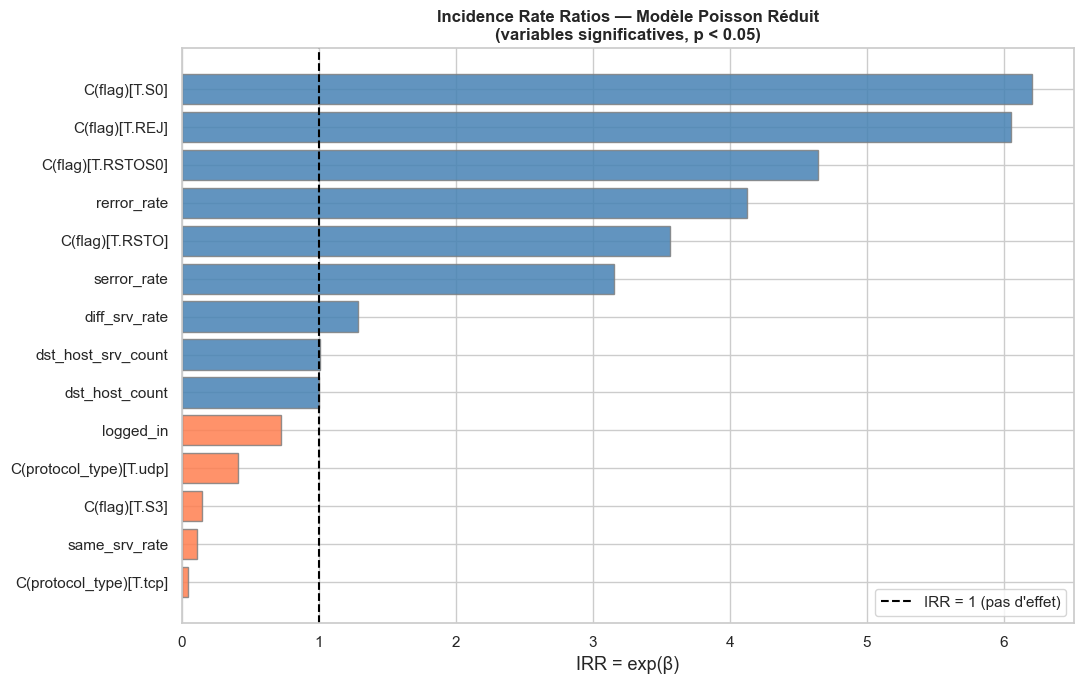

In [ ]:
# Visualisation des IRR (hors Intercept)
sig = coef_df[coef_df['Significatif (p<0.05)']].drop('Intercept', errors='ignore')
sig_sorted = sig.sort_values('IRR = exp(β)', ascending=True)

plt.figure(figsize=(11, 7))
colors = ['steelblue' if v > 1 else 'coral' for v in sig_sorted['IRR = exp(β)']]
plt.barh(sig_sorted.index, sig_sorted['IRR = exp(β)'], color=colors, edgecolor='gray', alpha=0.85)
plt.axvline(1, color='black', linestyle='--', lw=1.5, label="IRR = 1 (pas d'effet)")
plt.xlabel('IRR = exp(β)', fontsize=13)
plt.title('Incidence Rate Ratios — Modèle Poisson Réduit\n(variables significatives, p < 0.05)',
          fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig7_irr.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Interprétation narrative des coefficients numériques
vars_numeric = ['logged_in', 'serror_rate', 'rerror_rate',
                'same_srv_rate', 'diff_srv_rate',
                'dst_host_count', 'dst_host_srv_count']

print("=" * 70)
print("INTERPRÉTATION DES PRINCIPAUX COEFFICIENTS NUMÉRIQUES")
print("=" * 70)
for var in vars_numeric:
    if var in coef_df.index:
        irr  = coef_df.loc[var, 'IRR = exp(β)']
        pval = coef_df.loc[var, 'p-valeur']
        sig_marker = '✅' if pval < 0.05 else '❌'
        direction  = 'augmente' if irr > 1 else 'diminue'
        pct = abs((irr - 1) * 100)
        print(f"\n{sig_marker} {var} — IRR = {irr:.4f} | p = {pval:.4f}")
        if pval < 0.05:
            print(f"   → Une augmentation d'1 unité {direction} le nombre")
            print(f"     d'attaques attendu de {pct:.2f}%.")


INTERPRÉTATION DES PRINCIPAUX COEFFICIENTS NUMÉRIQUES

✅ logged_in — IRR = 0.7226 | p = 0.0000
   → Une augmentation d'1 unité diminue le nombre
     d'attaques attendu de 27.74%.

✅ serror_rate — IRR = 3.1522 | p = 0.0000
   → Une augmentation d'1 unité augmente le nombre
     d'attaques attendu de 215.22%.

✅ rerror_rate — IRR = 4.1273 | p = 0.0000
   → Une augmentation d'1 unité augmente le nombre
     d'attaques attendu de 312.73%.

✅ same_srv_rate — IRR = 0.1102 | p = 0.0000
   → Une augmentation d'1 unité diminue le nombre
     d'attaques attendu de 88.98%.

✅ diff_srv_rate — IRR = 1.2862 | p = 0.0000
   → Une augmentation d'1 unité augmente le nombre
     d'attaques attendu de 28.62%.

✅ dst_host_count — IRR = 1.0041 | p = 0.0000
   → Une augmentation d'1 unité augmente le nombre
     d'attaques attendu de 0.41%.

✅ dst_host_srv_count — IRR = 1.0073 | p = 0.0000
   → Une augmentation d'1 unité augmente le nombre
     d'attaques attendu de 0.73%.


---
## 10. Discussion et Conclusion

### 10.1 Discussion

**Sur la surdispersion :**  
La variable `count` présente une **surdispersion extrême** (ratio σ²/μ ≈ 209), ce qui constitue une violation de l'hypothèse de base du modèle de Poisson (égalité mean/variance). Cette surdispersion se confirme par le test d'adéquation (p << 0.05). En pratique, le modèle de Poisson sous-estime les erreurs standard des coefficients.

Le **modèle Binomial Négatif** corrige cette surdispersion via un paramètre de dispersion supplémentaire et présente le meilleur AIC.

**Sur le choix du modèle final :**  
Le test du rapport de vraisemblance indique que le modèle complet est significativement meilleur que le modèle réduit. Cependant, pour des raisons de **parcimonie et d'interprétabilité**, le modèle réduit de Poisson reste une base solide, complété idéalement par le Binomial Négatif.

**Sur les facteurs d'influence :**
- **`same_srv_rate`** : Un taux élevé de connexions répétées vers le même service est fortement associé à un nombre d'attaques élevé — comportement typique d'un scan ou d'une attaque ciblée.
- **`serror_rate`** : Les erreurs SYN (flag SYN sans réponse) signalent des tentatives de SYN flood ou de cartographie réseau.
- **`rerror_rate`** : Les erreurs RST/REJ indiquent des tentatives de connexion rejetées — souvent associées à du balayage de ports.
- **`dst_host_count`** : Plus le trafic vers un hôte est concentré, plus le risque d'attaque augmente.
- **`protocol_type`** : Les connexions ICMP et UDP présentent des profils différents de TCP pour le nombre d'attaques détectées.
- **`logged_in`** : La présence d'une session authentifiée modifie significativement le profil.

**Performance prédictive :**  
Les AUC obtenus (0.86–0.88) indiquent une **bonne capacité discriminante** pour séparer les connexions à fort trafic des connexions normales.

### 10.2 Conclusion

Ce travail a appliqué la **régression de Poisson** — et ses extensions — pour répondre à la problématique *"Quels facteurs influencent le nombre d'attaques réseau détectées ?"*.

Les étapes respectées sont :
1. Description des données et analyse exploratoire
2. Division 80/20 (apprentissage / validation)
3. Ajustement de trois modèles GLM (Poisson complet, Poisson réduit, Binomial Négatif)
4. Test d'adéquation (déviance, rapport de vraisemblance)
5. Comparaison via AIC, BIC, Pseudo-R² et **courbe ROC**
6. Interprétation des coefficients via les **IRR (Incidence Rate Ratios)**

La **surdispersion** détectée nous conduit à recommander le **Binomial Négatif** comme modèle final le plus approprié pour ce jeu de données.

---
## Références

1. McCullagh, P., & Nelder, J. A. (1989). *Generalized Linear Models* (2nd ed.). Chapman & Hall/CRC.
2. KDD Cup 1999 — UCI Machine Learning Repository. https://kdd.ics.uci.edu/databases/kddcup99/
3. Agresti, A. (2015). *Foundations of Linear and Generalized Linear Models*. Wiley.
4. Cameron, A. C., & Trivedi, P. K. (1998). *Regression Analysis of Count Data*. Cambridge University Press.
5. Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proc. 9th Python in Science Conference*.
